In [ ]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import netket.experimental as nkx
from NES_VMC import NESTotalAnsatz, create_machine,init_sampler_state,\
    generate_random_initial_states,ha,SingleStateAnsatz,create_single_machine,\
        create_machine_matrix,Ham_psi,Ham_Psi,NES_loss_energy,nes_vmc_gradient,hi,E_fcis,mcmc_sampler_multichain,\
        NESFermionHopRule,compute_qgt,sampler_info
import optax
from typing import Callable
from functools import partial
from jax.flatten_util import ravel_pytree
import time

# ========== 你原有全局参数（直接复用） ==========
# 単一システム希尔ベルト空間
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)
K = 3  # NES 拡張コピー数
hi_ext = hi ** K  # 拡張希尔ベルト空間
SINGLE_SIZE = hi.size  # 単一サブシステム次元 = 4
single_edges = ((0, 1), (2, 3))  # フェルミオンホッピング辺
g = nk.graph.Graph(edges=single_edges)
single_rule = nk.sampler.rules.FermionHopRule(hi, graph=g)
tensor_rule = nk.sampler.rules.TensorRule(hi_ext, [single_rule] * K)

total_ansatz = NESTotalAnsatz(4,K,12,rngs=nnx.Rngs(11))
total_machine, total_graphdef,total_params = create_machine(total_ansatz)
total_matrix_machine, total_graphdef,total_params = create_machine_matrix(total_ansatz)

single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, g, p = create_single_machine(ansatz)
    single_machine_list.append(m)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can plot data with JsonLog.data['Energy'][:-30].plot().

H₂ FCI ベンチマークエネルギー
E0 = -1.01546825 Ha  |  励起エネルギー：0.0000 eV
E1 = -0.87542794 Ha  |  励起エネルギー：3.8107 eV
E2 = -0.42938376 Ha  |  励起エネルギー：15.9482 eV
E3 = -0.26922131 Ha  |  励起エネルギー：20.3064 eV


In [2]:
import jax
import jax.numpy as jnp
import netket as nk

SINGLE_SIZE = hi.size

@nk.utils.struct.dataclass
class NESFermionHopRule(nk.sampler.rules.MetropolisRule):
    edges: jnp.ndarray
    K: int = nk.utils.struct.static_field()
    single_size: int = nk.utils.struct.static_field()

    def _check_duplicate(self, sigma_ext):
        """NES制約：子组态不重复
        🔥 コア修正：返回【标量布尔值】，匹配while_loop初始值形状
        """
        sub = sigma_ext.reshape((-1, self.K, self.single_size))
        # 原代码返回数组 → 改为 .squeeze() 压缩成标量！
        return jnp.any(jnp.all(sub[...,1:,:] == sub[...,0:1,:], axis=-1), axis=-1).squeeze()

    def transition(self, sampler, machine, parameters, state, rng, sigma):
        """遷移規則（完全不变）"""
        batch_size = sigma.shape[0]
        key1, key2 = jax.random.split(rng)

        e_idx = jax.random.randint(key1, (batch_size,), 0, self.edges.shape[0])
        sel_e = self.edges[e_idx]
        i, j = sel_e[:,0], sel_e[:,1]

        sigma_cand = sigma.at[jnp.arange(batch_size),i].set(sigma[jnp.arange(batch_size),j])
        sigma_cand = sigma_cand.at[jnp.arange(batch_size),j].set(sigma[jnp.arange(batch_size),i])

        invalid = self._check_duplicate(sigma_cand)
        new_sigma = jnp.where(invalid[:, None], sigma, sigma_cand)

        return new_sigma, None

    def random_state(self, sampler, machine, parameters, state, rng):
        """ランダム状態生成（仅修复标量形状）"""
        sigma_shape = state.σ.shape
        hilbert = sampler.hilbert

        def gen_single(key):
            max_tries = 100
            def cond(c): 
                return (c[0] < max_tries) & c[2]
            
            def body(c):
                tries, k, _, _ = c
                k, k_new = jax.random.split(k)
                s = hilbert.random_state(k_new)
                is_dup = self._check_duplicate(s)  # 现在是标量！
                return (tries + 1, k, is_dup, s)
            
            # 初始值 c[2] = True（标量布尔值），和body返回值形状完全匹配
            init_c = (0, key, True, hilbert.random_state(key))
            final_c = jax.lax.while_loop(cond, body, init_c)
            tries, _, is_dup, s = final_c
            return jax.lax.cond(is_dup, lambda: hilbert.random_state(key), lambda: s)
        
        keys = jax.random.split(rng, sigma_shape[0])
        return jax.vmap(gen_single)(keys)

In [ ]:
N_CHAINS = 16
N_WARMUP = 100
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 30
N_ITER =400
SINGLE_SIZE = hi.size  # 単一サブシステム次元 = 4
Natural_Grad = False


total_ansatz = NESTotalAnsatz(4,K,12,rngs=nnx.Rngs(11))
total_machine, total_graphdef,total_params = create_machine(total_ansatz)
total_matrix_machine, total_graphdef,total_params = create_machine_matrix(total_ansatz)

single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, g, p = create_single_machine(ansatz)
    single_machine_list.append(m)
    
    

optimizer = optax.sgd(learning_rate=0.01)
opt_state = optimizer.init(total_params)

ext_edges = []
for k in range(K):
    offset = k * SINGLE_SIZE
    for (i, j) in single_edges:
        ext_edges.append((i + offset, j + offset))
ext_edges = jnp.array(ext_edges)  # jax配列に変換（重要な修正）

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=16,
    sweep_size=20
)


# サンプラー状態初期化（替代原 init_sampler_state）
sampler_rng = jax.random.PRNGKey(21)
sampler_state = nes_sampler.init_state(total_machine, total_params, sampler_rng)

# ==================== トレーニングループ（仅替换采样部分） ====================
print("\n" + "="*60)
print("多連NES-VMCトレーニング開始 (NetKet 自定义采样器 + 朴素梯度下降)")
print("="*60)
print(f"基底状態エネルギー={E_fcis[0]:.8f} Ha| 第一励起状態エネルギー={E_fcis[1]:.8f} Ha| 第二励起状態エネルギー={E_fcis[2]:.8f} Ha")

history = {
    'step': [],
    'energy_0st': [],
    'energy_1st': [],
    'energy_2st': [],
    'energy_std': [],
    'loss': [],
    'params': [],
    'E_Lmatrix':[],
    'natural_grad':[],
    'grad_flat':[],
    'samples':[],
    'log_Psi':[],
    'log_M':[],
    'log_Psi_mean':[],
    'log_Psi_min':[],
    'log_Psi_max':[],
    'grad_norm':[],
}

start_time = time.time()
for step in range(N_ITER):
    # 2. 正式サンプリング
    samples_raw, sampler_state = nes_sampler.sample(
        machine=total_machine, parameters=total_params, 
        state=sampler_state, chain_length=N_SAMPLES_PER_CHAIN
    )
        # 3. 次元再形成，适配梯度函数输入
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, 4)
    # 3. 计算エネルギー和自然梯度（逻辑和原代码一致）
    grad, loss_mean, E_L_mean = nes_vmc_gradient(ha=ha,
                                                 total_matrix_machine=total_matrix_machine,
                                                 total_machine=total_machine,
                                                 single_machine_list=single_machine_list,
                                                 total_params=total_params,
                                                 x_batch=samples.reshape(-1,K,4))
    grad_flat , grad_unravel_fn = ravel_pytree(grad)
    #grad = jax.tree_util.tree_map(lambda x: x * 2, grad)
    if Natural_Grad == True:
        qgt_reg, unravel_fn = compute_qgt(total_machine, total_params, samples.reshape(-1,K,4), diag_shift=0.1)
        # # 自然梯度求解
        natural_grad_flat = jnp.linalg.solve(qgt_reg, grad_flat)
        natural_grad = grad_unravel_fn(natural_grad_flat)
        grad = natural_grad
        
    # 4. 更新参数
    updates, opt_state = optimizer.update(grad, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)
    
    
    
    log_Psi_batch = total_machine(total_params, samples.reshape(-1,K,4))
    eig_vals, eig_vecs = jnp.linalg.eigh(E_L_mean)
    grad_norm = jnp.linalg.norm(grad_flat)
    
    
    history['step'].append(step)
    history['E_Lmatrix'].append(E_L_mean)
    history['samples'].append(samples)
    history['loss'].append(loss_mean)
    history['log_Psi_mean'].append(log_Psi_batch.mean())
    history['log_Psi_min'].append(log_Psi_batch.min())
    history['log_Psi_max'].append(log_Psi_batch.max())
    history['grad_norm'].append(grad_norm)
    history['energy_0st'].append(eig_vals[0])
    history['energy_1st'].append(eig_vals[1])
    history['energy_2st'].append(eig_vals[2])
    history['params'].append(total_params)
    # 5. 履歴を記録
    if step % 50 == 0 or step == N_ITER - 1:
        # --------------------- 【NES-VMC 监控模板】直接用 ---------------------
        # 1. log_Psiを監視
        #log_Psi_batch = total_machine(total_params, samples.reshape(-1,K,4))
        print(f"log_Psi: 平均={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")

        # 2. 勾配 нормを監視
        
        print(f"勾配 норм = {grad_norm:.4f}")
        print(f"ステップ {step:3d} | 損失: {loss_mean}|0次エネルギー={eig_vals[0]:.8f} Ha｜1次エネルギー={eig_vals[1]:.8f} Ha｜2次エネルギー={eig_vals[2]:.8f} Ha")
        # print(f'grad={grad_flat[30:31]}')
        print('#-----------------------------------------#')


end_time = time.time()
print(f"トレーニング時間：{end_time - start_time:.2f} 秒")
# 最终结果
print("\n" + "="*60)
print(f"トレーニング完了!")
print("="*60)


多連NES-VMCトレーニング開始 (NetKet 自定义采样器 + 朴素梯度下降)
基底状態エネルギー=-1.01546825 Ha| 第一励起状態エネルギー=-0.87542794 Ha| 第二励起状態エネルギー=-0.42938376 Ha
log_Psi: 平均=0.963-0.313j | min=0.608-2.244j | max=1.052+1.123j
勾配 норм = 0.0109
ステップ   0 | 損失: -1.9097975073079871|0次エネルギー=-1.71489196 Ha｜1次エネルギー=-0.72822434 Ha｜2次エネルギー=0.53331879 Ha
#-----------------------------------------#
log_Psi: 平均=0.999-0.289j | min=-0.175-2.074j | max=1.223+0.908j
勾配 норм = 0.0109
ステップ  50 | 損失: -2.236586343058429|0次エネルギー=-1.46979341 Ha｜1次エネルギー=-0.87094699 Ha｜2次エネルギー=0.10415405 Ha
#-----------------------------------------#
log_Psi: 平均=1.013-0.264j | min=-0.116-2.077j | max=1.252+0.930j
勾配 норм = 0.0109
ステップ 100 | 損失: -2.2535030070529105|0次エネルギー=-1.47850942 Ha｜1次エネルギー=-0.86766047 Ha｜2次エネルギー=0.09266689 Ha
#-----------------------------------------#
log_Psi: 平均=1.025-0.282j | min=-0.061-2.104j | max=1.296+0.913j
勾配 норм = 0.0109
ステップ 150 | 損失: -2.25575251959676|0次エネルギー=-1.49911159 Ha｜1次エネルギー=-0.86455377 Ha｜2次エネルギー=0.10791284 Ha
#----------

$$
\begin{align*}
\Psi(\mathbf{x})^{-1}\hat{\mathcal{H}}\Psi(\mathbf{x})
&= \mathrm{Tr}\left[ \Psi^{-1}(\mathbf{x})\hat{H}\Psi(\mathbf{x}) \right]
\end{align*}
$$

In [28]:
import pickle
import os  # 加上这个
# 自动创建 data 文件夹（重要な修正）
os.makedirs('./data', exist_ok=True)
if Natural_Grad == True:
    print('自然勾配履歴を保存')
    # 保存 history
    with open('./data/history_natural_gradient_K3.pkl', 'wb') as f:
        pickle.dump(history, f)
else:
    # 保存 history
    with open('./data/history_plain_gradient_K3.pkl', 'wb') as f:
        pickle.dump(history, f)

print("保存成功！")

保存成功！


In [1]:
import pickle
history_natural= pickle.load(open('./data/history_natural_gradient_K3.pkl', 'rb'))
history_plain= pickle.load(open('./data/history_plain_gradient_K3.pkl', 'rb'))


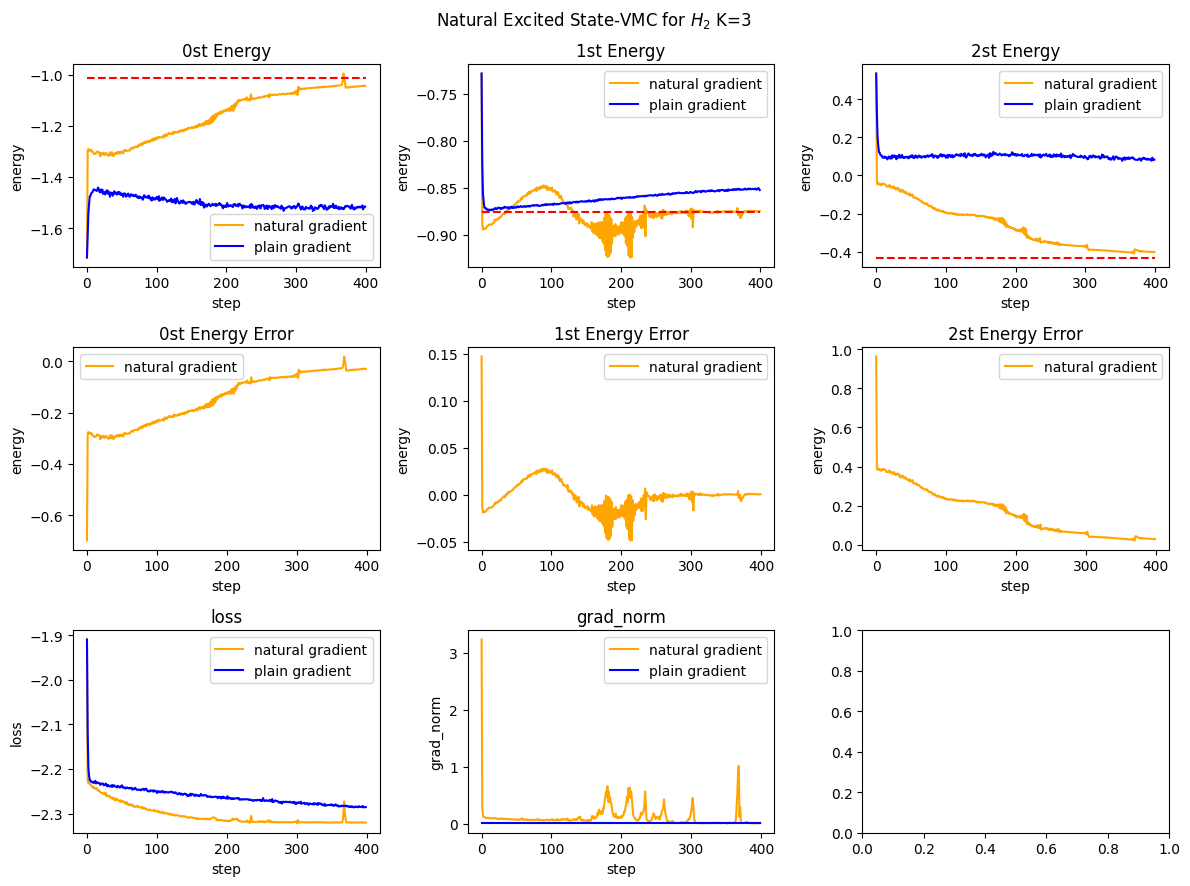

In [ ]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from NES_VMC import E_fcis

# 创建 2行1列 的子图
fig, axs = plt.subplots(3, 3, figsize=(12, 9))
fig.suptitle('Natural Excited State-VMC for $H_2$ K=3 ')
# 第一个子图
axs[0,0].plot(history_natural['energy_0st'],color='orange',label='natural gradient')
axs[0,0].plot(history_plain['energy_0st'],color='blue',label='plain gradient')
axs[0,0].hlines(E_fcis[0],0,len(history_natural['energy_0st']),linestyle='--',color='red')
axs[0,0].set_title('0st Energy')
axs[0,0].set_ylabel('energy')
axs[0,0].set_xlabel('step')
axs[0,0].set_xlabel('step')
axs[0,0].legend()

axs[0,1].plot(history_natural['energy_1st'],color='orange',label='natural gradient')
axs[0,1].plot(history_plain['energy_1st'],color='blue',label='plain gradient')
axs[0,1].hlines(E_fcis[1],0,len(history_natural['energy_1st']),linestyle='--',color='red')
axs[0,1].set_title('1st Energy')
axs[0,1].set_ylabel('energy')
axs[0,1].set_xlabel('step')      
axs[0,1].legend()

axs[0,2].plot(history_natural['energy_2st'],color='orange',label='natural gradient')
axs[0,2].plot(history_plain['energy_2st'],color='blue',label='plain gradient')
axs[0,2].hlines(E_fcis[2],0,len(history_natural['energy_2st']),linestyle='--',color='red')
axs[0,2].set_title('2st Energy')
axs[0,2].set_ylabel('energy')
axs[0,2].set_xlabel('step')      
axs[0,2].legend()


# # 第二个子图
axs[1,0].plot(history_natural['energy_0st']-E_fcis[0],color='orange',label='natural gradient')    
axs[1,0].set_title('0st Energy Error')
axs[1,0].set_xlabel('step')
axs[1,0].set_ylabel('energy')
axs[1,0].legend()



axs[1,1].plot(history_natural['energy_1st']-E_fcis[1],color='orange',label='natural gradient')    
axs[1,1].set_title('1st Energy Error')
axs[1,1].set_xlabel('step')
axs[1,1].set_ylabel('energy')
axs[1,1].legend()

axs[1,2].plot(history_natural['energy_2st']-E_fcis[2],color='orange',label='natural gradient')    
axs[1,2].set_title('2st Energy Error')
axs[1,2].set_xlabel('step')
axs[1,2].set_ylabel('energy')
axs[1,2].legend()


# # 第二个子图
axs[2,0].plot(history_natural['loss'],color='orange',label='natural gradient')  
axs[2,0].plot(history_plain['loss'],color='blue',label='plain gradient')
axs[2,0].set_title('loss')
axs[2,0].set_xlabel('step')
axs[2,0].set_ylabel('loss')
axs[2,0].legend()

axs[2,1].plot(history_natural['grad_norm'],color='orange',label='natural gradient')  
axs[2,1].plot(history_plain['grad_norm'],color='blue',label='plain gradient')
axs[2,1].set_title('grad_norm')
axs[2,1].set_xlabel('step')
axs[2,1].set_ylabel('grad_norm')
axs[2,1].legend()

plt.tight_layout()  # 自动调整间距
plt.show()

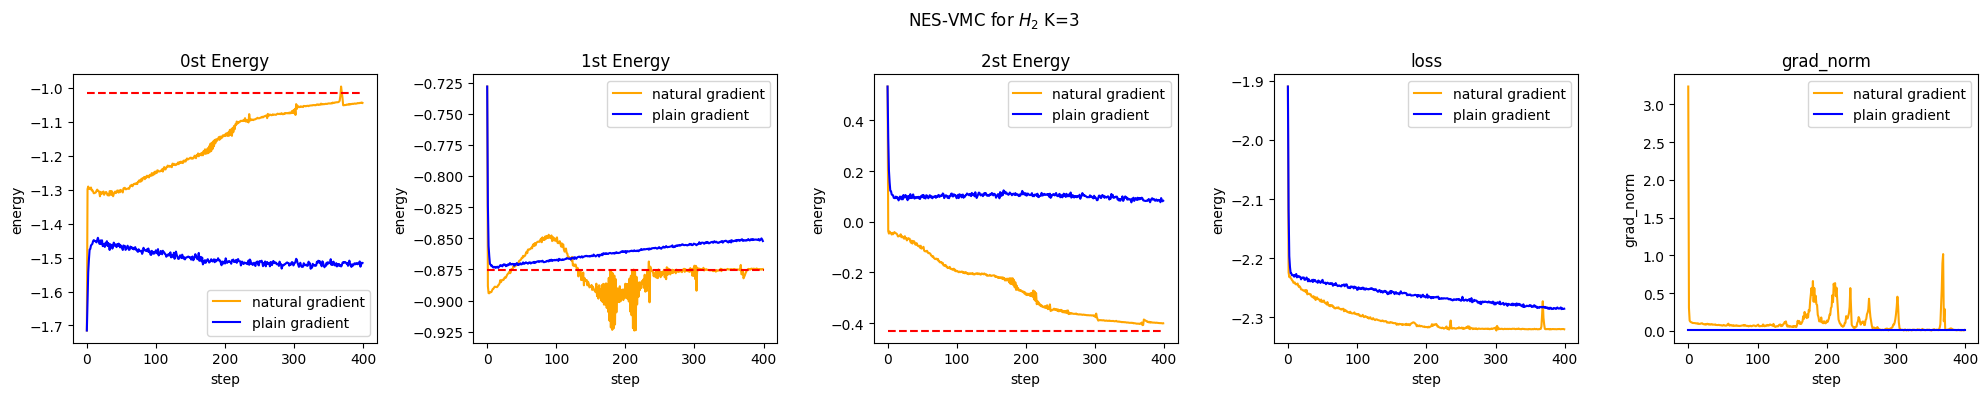

In [59]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from NES_VMC import E_fcis

# 创建 2行1列 的子图
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('NES-VMC for $H_2$ K=3 ')
# 第一个子图
axs[0].plot(history_natural['energy_0st'],color='orange',label='natural gradient')
axs[0].plot(history_plain['energy_0st'],color='blue',label='plain gradient')
axs[0].hlines(E_fcis[0],0,len(history_natural['energy_0st']),linestyle='--',color='red')
axs[0].set_title('0st Energy')
axs[0].set_ylabel('energy')
axs[0].set_xlabel('step')
axs[0].legend()

axs[1].plot(history_natural['energy_1st'],color='orange',label='natural gradient')
axs[1].plot(history_plain['energy_1st'],color='blue',label='plain gradient')
axs[1].hlines(E_fcis[1],0,len(history_natural['energy_1st']),linestyle='--',color='red')
axs[1].set_title('1st Energy')
axs[1].set_ylabel('energy')
axs[1].set_xlabel('step')      
axs[1].legend()

axs[2].plot(history_natural['energy_2st'],color='orange',label='natural gradient')
axs[2].plot(history_plain['energy_2st'],color='blue',label='plain gradient')
axs[2].hlines(E_fcis[2],0,len(history_natural['energy_2st']),linestyle='--',color='red')
axs[2].set_title('2st Energy')
axs[2].set_ylabel('energy')
axs[2].set_xlabel('step')      
axs[2].legend()


# 第二个子图
axs[3].plot(history_natural['loss'],color='orange',label='natural gradient')            
axs[3].plot(history_plain['loss'],color='blue',label='plain gradient')
axs[3].set_title('loss')
axs[3].set_xlabel('step')
axs[3].set_ylabel('energy')
axs[3].legend()

# 第三个子图
axs[4].plot(history_natural['grad_norm'],color='orange',label='natural gradient')
axs[4].plot(history_plain['grad_norm'],color='blue',label='plain gradient')
axs[4].set_title('grad_norm')
axs[4].set_xlabel('step')
axs[4].set_ylabel('grad_norm')
axs[4].legend()

plt.tight_layout()  # 自动调整间距
plt.show()

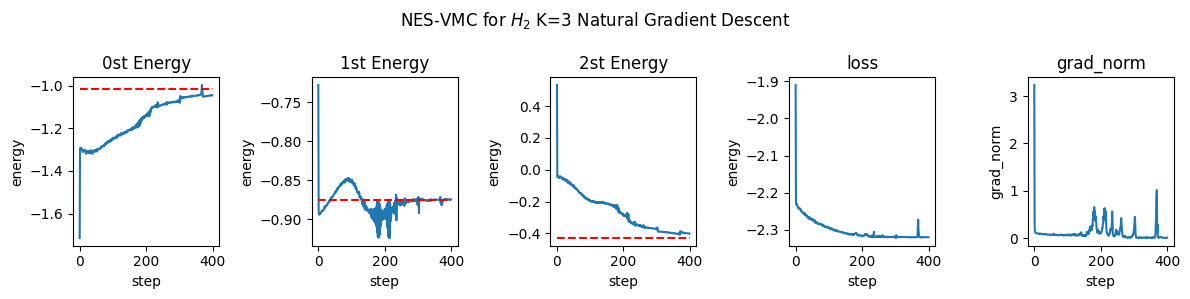

In [11]:
import matplotlib.pyplot as plt

# 创建 2行1列 的子图
fig, axs = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle('NES-VMC for $H_2$ K=3 Natural Gradient Descent')
# 第一个子图
axs[0].plot(history['energy_0st'])
axs[0].hlines(E_fcis[0],0,len(history['energy_0st']),linestyle='--',color='red')
axs[0].set_title('0st Energy')
axs[0].set_ylabel('energy')
axs[0].set_xlabel('step')

axs[1].plot(history['energy_1st'])
axs[1].hlines(E_fcis[1],0,len(history['energy_1st']),linestyle='--',color='red')
axs[1].set_title('1st Energy')
axs[1].set_ylabel('energy')
axs[1].set_xlabel('step')

axs[2].plot(history['energy_2st'])
axs[2].hlines(E_fcis[2],0,len(history['energy_2st']),linestyle='--',color='red')
axs[2].set_title('2st Energy')
axs[2].set_ylabel('energy')
axs[2].set_xlabel('step')

# 第二个子图
axs[3].plot(history['loss'])
axs[3].set_title('loss')
axs[3].set_xlabel('step')
axs[3].set_ylabel('energy')

# 第三个子图
axs[4].plot(history['grad_norm'])
axs[4].set_title('grad_norm')
axs[4].set_xlabel('step')
axs[4].set_ylabel('grad_norm')

plt.tight_layout()  # 自动调整间距
plt.show()